# MotorNet-JAX: Training Neural Networks

This notebook demonstrates how to train neural network controllers for reaching tasks using MotorNet-JAX.

In [1]:
import os
import sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath('.')))))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import optax
import equinox as eqx

import motornet_jax as mn
from motornet_jax.types import JointState
from motornet_jax.effector import Arm26
from motornet_jax.policy import GRUPolicy
from motornet_jax.skeleton import TwoDofArm

print('All packages imported.')
print(f'JAX version: {jax.__version__}')
print(f'Equinox version: {eqx.__version__}')
print(f'Optax version: {optax.__version__}')

# Show device information
print(f'\n--- Device Configuration ---')
print(f'Backend: {jax.default_backend()}')
print(f'Devices: {jax.devices()}')

All packages imported.
JAX version: 0.9.0
Equinox version: 0.13.4
Optax version: 0.2.6

--- Device Configuration ---
Backend: cpu
Devices: [CpuDevice(id=0)]


In [2]:
# === Device Configuration ===
# JAX automatically uses the best available backend. To enable GPU:
#
# For NVIDIA GPUs (CUDA):
#   pip install jax[cuda12_pip] -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
#
# For Apple Silicon (Metal/MPS):
#   pip install jax-metal
#
# To force a specific device:
#   jax.config.update('jax_default_device', jax.devices('gpu')[0])  # Use first GPU
#   jax.config.update('jax_default_device', jax.devices('cpu')[0])  # Force CPU

# Check if GPU is available and set as default
def setup_device(prefer_gpu=True):
    """Setup JAX device. Returns the device being used."""
    backend = jax.default_backend()
    devices = jax.devices()
    
    if prefer_gpu and backend in ['gpu', 'cuda', 'metal']:
        device = devices[0]
        print(f"Using GPU: {device}")
    else:
        device = jax.devices('cpu')[0]
        if prefer_gpu:
            print(f"GPU not available, using CPU: {device}")
        else:
            print(f"Using CPU: {device}")
    
    return device

device = setup_device(prefer_gpu=True)
print(f"All computations will run on: {device}")

GPU not available, using CPU: TFRT_CPU_0
All computations will run on: TFRT_CPU_0


## I. Setup

We'll train a GRU policy to perform center-out reaching movements.

In [3]:
# Create arm and policy
arm = Arm26(dt=0.01, n_ministeps=1)
arm_params = arm.get_params()
skeleton = TwoDofArm()
skeleton_params = skeleton.get_params()

# Policy configuration
obs_dim = 6    # hand position (2) + hand velocity (2) + target (2)
action_dim = 6  # 6 muscles
hidden_size = 256

key = jax.random.PRNGKey(0)
# GRUPolicy(obs_dim, action_dim, hidden_size, n_gru_layers, key)
policy = GRUPolicy(obs_dim, action_dim, hidden_size=hidden_size, n_gru_layers=1, key=key)

print(f"Policy architecture:")
print(f"  Observation dim: {obs_dim}")
print(f"  Action dim: {action_dim}")
print(f"  Hidden size: {hidden_size}")
print(f"\nNumber of parameters: {sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(policy, eqx.is_array)))}")

Policy architecture:
  Observation dim: 6
  Action dim: 6
  Hidden size: 256

Number of parameters: 397574


## II. Task Definition

Center-out reaching: start from center, reach to targets arranged in a circle.

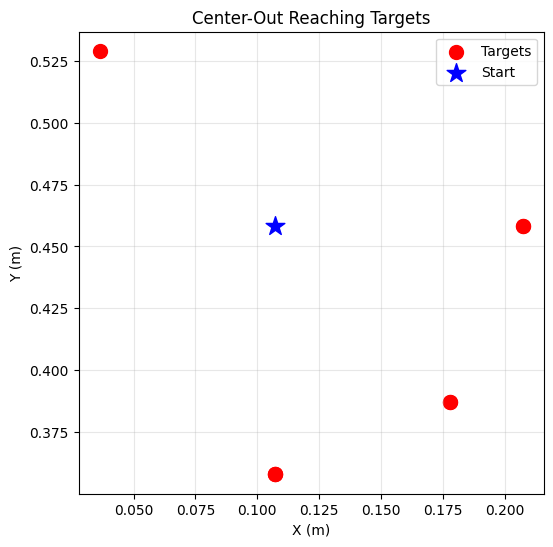

In [4]:
def generate_targets(key, batch_size, n_targets=8, radius=0.1):
    """Generate center-out reaching targets."""
    # Random target directions
    key, subkey = jax.random.split(key)
    target_indices = jax.random.randint(subkey, (batch_size,), 0, n_targets)
    angles = target_indices * (2 * jnp.pi / n_targets)
    
    # Center position (in Cartesian space)
    center_joint = jnp.array([[0.8, 1.2]])  # Shoulder, elbow angles
    center_state = JointState(
        position=center_joint,
        velocity=jnp.zeros((1, 2)),
    )
    _, center_hand, _, _ = TwoDofArm.forward_kinematics(center_state, skeleton_params)
    center = center_hand[0]  # (2,)
    
    # Target positions
    targets = center + radius * jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)
    
    return targets, center_joint

# Visualize targets
key = jax.random.PRNGKey(0)
targets, center_joint = generate_targets(key, 8)

plt.figure(figsize=(6, 6))
plt.scatter(targets[:, 0], targets[:, 1], s=100, c='red', label='Targets')
center_state = JointState(position=center_joint, velocity=jnp.zeros((1, 2)))
_, center_hand, _, _ = TwoDofArm.forward_kinematics(center_state, skeleton_params)
plt.scatter(center_hand[0, 0], center_hand[0, 1], s=200, c='blue', marker='*', label='Start')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Center-Out Reaching Targets')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## III. Loss Function

Following the PyTorch MotorNet approach, we use:
- **L1 loss (absolute error)** on the **full trajectory** - not just the endpoint
- **Effort cost**: Penalty on squared muscle activations (metabolic cost proxy)
- **Jerk penalty**: Penalty on movement smoothness (3rd derivative of position)
- The target is broadcast across all timesteps (reach and hold)
- Gradient clipping (max_norm=1.0) for stable training

In [5]:
# Loss function using L1 on full trajectory + effort + jerk penalties (matching PyTorch MotorNet)
def compute_loss(policy, arm_states, targets, n_steps=100, 
                 effort_weight=1e-4, jerk_weight=1e-6):
    """
    Compute loss with multiple components:
    
    1. L1 (absolute) position error on FULL trajectory
    2. Effort cost: mean squared muscle activation (metabolic cost proxy)
    3. Jerk penalty: smoothness regularization (3rd derivative of position)
    
    Args:
        policy: GRU policy network
        arm_states: Initial arm states (batched)
        targets: Target positions (batch, 2)
        n_steps: Number of simulation steps
        effort_weight: Weight for effort cost term
        jerk_weight: Weight for jerk penalty term
    """
    batch_size = targets.shape[0]
    hidden = policy.init_hidden(batch_size)
    
    def step_fn(carry, _):
        state, hidden = carry
        
        # Build observation for entire batch
        obs = jnp.concatenate([
            state.fingertip,           # (batch, 2)
            state.cartesian.velocity,  # (batch, 2)
            targets,                   # (batch, 2)
        ], axis=-1)  # (batch, 6)
        
        # Get action from policy
        action, new_hidden = policy(obs, hidden)
        
        # Step simulation for entire batch
        new_state = Arm26.step(
            state, action,
            jnp.zeros((batch_size, 2)), jnp.zeros((batch_size, 2)),
            arm_params
        )
        
        # Return new state AND current fingertip position + action for loss
        return (new_state, new_hidden), (new_state.fingertip, action)
    
    # Run simulation and collect ALL fingertip positions and actions
    (final_state, _), (trajectory, actions) = jax.lax.scan(
        step_fn, (arm_states, hidden), None, length=n_steps
    )
    # trajectory shape: (n_steps, batch, 2)
    # actions shape: (n_steps, batch, n_muscles)
    
    # === L1 Position Loss ===
    # Broadcast target to all timesteps: (n_steps, batch, 2)
    target_trajectory = jnp.broadcast_to(targets[None, :, :], trajectory.shape)
    l1_per_step = jnp.sum(jnp.abs(trajectory - target_trajectory), axis=-1)  # (n_steps, batch)
    position_loss = jnp.mean(l1_per_step)
    
    # === Effort Cost ===
    # Mean squared muscle activation (proxy for metabolic cost)
    effort = jnp.mean(actions ** 2)
    
    # === Jerk Penalty ===
    # Jerk = 3rd derivative of position (d³x/dt³)
    # Computed via finite differences: diff(diff(diff(position)))
    # This encourages smooth, minimum-jerk trajectories
    velocity = jnp.diff(trajectory, axis=0)  # (n_steps-1, batch, 2)
    acceleration = jnp.diff(velocity, axis=0)  # (n_steps-2, batch, 2)
    jerk = jnp.diff(acceleration, axis=0)  # (n_steps-3, batch, 2)
    jerk_penalty = jnp.mean(jerk ** 2)
    
    # === Total Loss ===
    loss = position_loss + effort_weight * effort + jerk_weight * jerk_penalty
    
    # Metrics for monitoring
    final_pos = trajectory[-1]  # (batch, 2)
    final_error = jnp.sqrt(jnp.sum((final_pos - targets) ** 2, axis=-1))  # (batch,)
    
    metrics = {
        'position_error': jnp.mean(final_error),
        'position_loss': position_loss,
        'effort': effort,
        'jerk': jerk_penalty,
        'total_loss': loss,
    }
    
    return loss, metrics

## IV. Training Loop

In [6]:
# Training configuration
batch_size = 32
n_steps = 100
n_epochs = 1000
learning_rate = 1e-3

# Optimizer with gradient clipping (matching PyTorch max_norm=1.0)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),  # Gradient clipping - critical for stability!
    optax.adam(learning_rate)
)
opt_state = optimizer.init(eqx.filter(policy, eqx.is_array))

# Loss and gradient function
@eqx.filter_jit
def train_step(policy, opt_state, arm_states, targets):
    """Single training step."""
    def loss_fn(policy):
        loss, metrics = compute_loss(policy, arm_states, targets, n_steps)
        return loss, metrics
    
    (loss, metrics), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(policy)
    
    updates, opt_state_new = optimizer.update(
        grads, opt_state, eqx.filter(policy, eqx.is_array)
    )
    policy_new = eqx.apply_updates(policy, updates)
    
    return policy_new, opt_state_new, loss, metrics

In [7]:
# Helper to create batched arm state
def create_batch_state(center_joint, batch_size):
    """Create batched arm state at center position."""
    joint_state = JointState(
        position=jnp.tile(center_joint, (batch_size, 1)),
        velocity=jnp.zeros((batch_size, 2)),
    )
    return arm.reset(batch_size=batch_size, joint_state=joint_state)

In [8]:
# Training loop
key = jax.random.PRNGKey(42)
history = {'loss': [], 'position_error': [], 'effort': [], 'jerk': []}

print("Starting training...")
print("(Using L1 loss + effort cost + jerk penalty with gradient clipping)")
print()

for epoch in range(n_epochs):
    key, target_key = jax.random.split(key)
    
    # Generate targets
    targets, center_joint = generate_targets(target_key, batch_size)
    
    # Create arm states (already batched correctly)
    arm_states = create_batch_state(center_joint, batch_size)
    
    # Training step
    policy, opt_state, loss, metrics = train_step(
        policy, opt_state, arm_states, targets
    )
    
    # Record history
    history['loss'].append(float(loss))
    history['position_error'].append(float(metrics['position_error']))
    history['effort'].append(float(metrics['effort']))
    history['jerk'].append(float(metrics['jerk']))
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d}: loss={loss:.4f}, "
              f"pos_err={metrics['position_error']*100:.2f}cm, "
              f"effort={metrics['effort']:.4f}, "
              f"jerk={metrics['jerk']:.2e}")

print("\nTraining complete!")
print(f"Final position error: {history['position_error'][-1]*100:.2f}cm")
print(f"Final effort: {history['effort'][-1]:.4f}")
print(f"Final jerk: {history['jerk'][-1]:.2e}")

Starting training...
(Using L1 loss + effort cost + jerk penalty with gradient clipping)

Epoch  100: loss=0.0567, pos_err=3.14cm, effort=0.2293, jerk=9.46e-09
Epoch  200: loss=0.0324, pos_err=1.13cm, effort=0.2312, jerk=6.23e-08
Epoch  300: loss=0.0261, pos_err=1.01cm, effort=0.2360, jerk=1.06e-07
Epoch  400: loss=0.0189, pos_err=0.16cm, effort=0.2365, jerk=1.58e-07
Epoch  500: loss=0.0201, pos_err=0.66cm, effort=0.2389, jerk=1.68e-07
Epoch  600: loss=0.0146, pos_err=0.29cm, effort=0.2360, jerk=1.72e-07
Epoch  700: loss=0.0172, pos_err=0.42cm, effort=0.2382, jerk=2.30e-07
Epoch  800: loss=0.0186, pos_err=0.65cm, effort=0.2375, jerk=2.63e-07
Epoch  900: loss=0.0129, pos_err=0.26cm, effort=0.2348, jerk=2.83e-07
Epoch 1000: loss=0.0134, pos_err=0.17cm, effort=0.2369, jerk=3.78e-07

Training complete!
Final position error: 0.17cm
Final effort: 0.2369
Final jerk: 3.78e-07


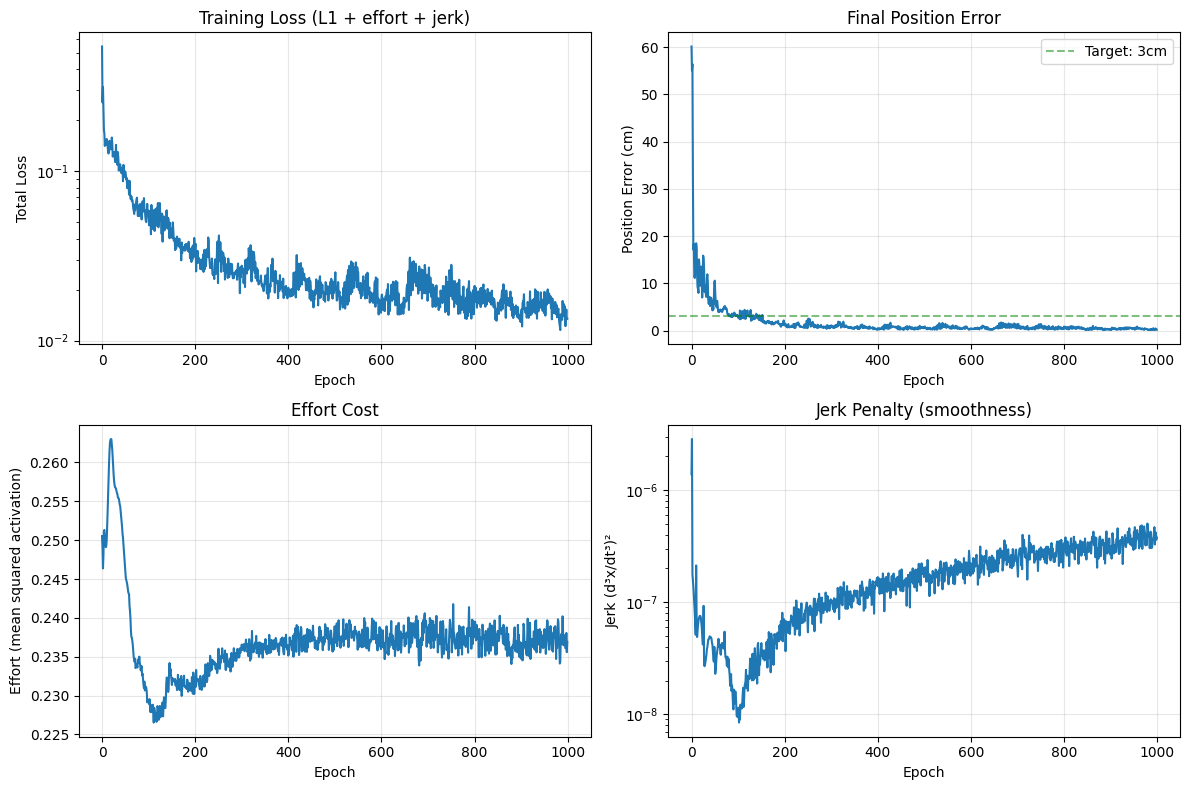

In [9]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(history['loss'])
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Training Loss (L1 + effort + jerk)')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot([e * 100 for e in history['position_error']])
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Position Error (cm)')
axes[0, 1].set_title('Final Position Error')
axes[0, 1].axhline(y=3, color='g', linestyle='--', alpha=0.5, label='Target: 3cm')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history['effort'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Effort (mean squared activation)')
axes[1, 0].set_title('Effort Cost')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].semilogy(history['jerk'])
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Jerk (d³x/dt³)²')
axes[1, 1].set_title('Jerk Penalty (smoothness)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## V. Evaluate Trained Policy

In [10]:
@jax.jit
def evaluate_trajectory(policy, arm_state, target, n_steps=100):
    """Generate trajectory from trained policy."""
    hidden = policy.init_hidden(1)
    
    def step_fn(carry, _):
        state, hidden = carry
        
        obs = jnp.concatenate([
            state.fingertip,
            state.cartesian.velocity,
            target[None, :],
        ], axis=-1)
        
        # Policy already applies sigmoid
        action, hidden = policy(obs, hidden)
        
        state = Arm26.step(
            state, action,
            jnp.zeros((1, 2)), jnp.zeros((1, 2)),
            arm_params
        )
        
        return (state, hidden), (state.fingertip[0], action[0])
    
    _, (positions, actions) = jax.lax.scan(
        step_fn, (arm_state, hidden), None, length=n_steps
    )
    
    return positions, actions

# Evaluate on all 8 targets
key = jax.random.PRNGKey(123)
targets, center_joint = generate_targets(key, 8)
arm_state = arm.reset(
    batch_size=1,
    joint_state=JointState(
        position=center_joint,
        velocity=jnp.zeros((1, 2)),
    )
)

all_trajectories = []
all_actions = []
for i in range(8):
    positions, actions = evaluate_trajectory(policy, arm_state, targets[i])
    all_trajectories.append(positions)
    all_actions.append(actions)

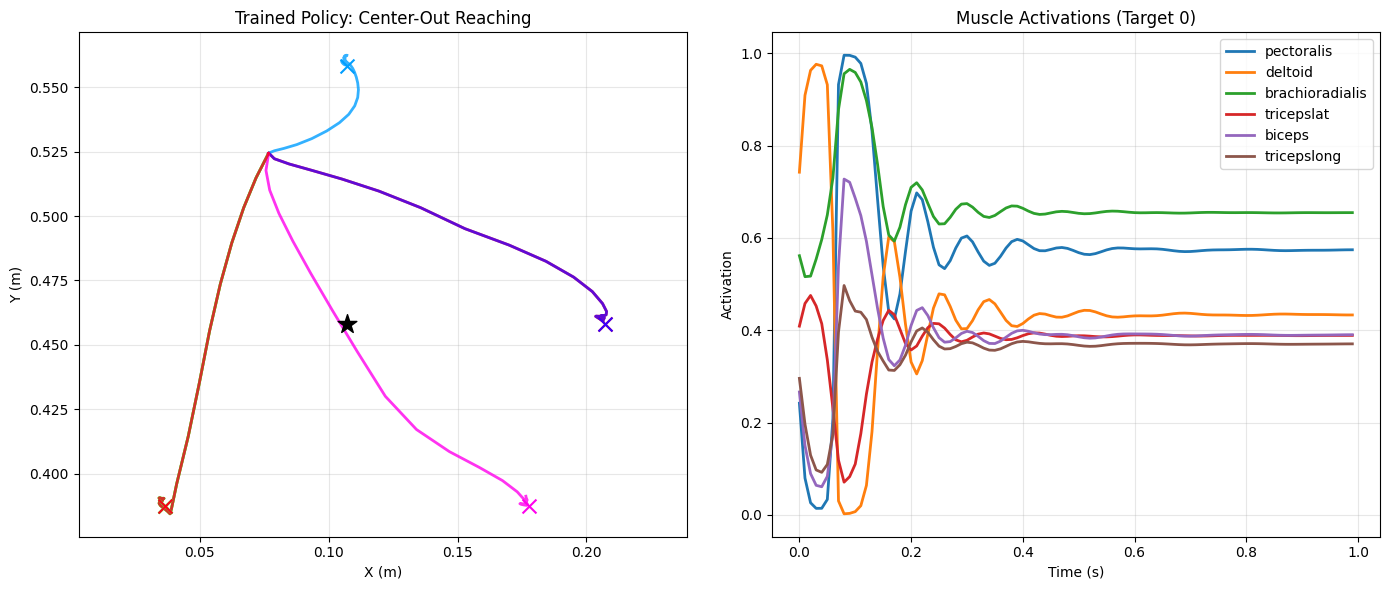

In [11]:
# Plot trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trajectory plot
ax = axes[0]
colors = plt.cm.hsv(np.linspace(0, 1, 8))

for i, (traj, target) in enumerate(zip(all_trajectories, targets)):
    ax.plot(traj[:, 0], traj[:, 1], color=colors[i], linewidth=2, alpha=0.8)
    ax.scatter([target[0]], [target[1]], color=colors[i], s=100, marker='x', zorder=5)

# Start position
_, center_hand, _, _ = TwoDofArm.forward_kinematics(
    JointState(position=center_joint, velocity=jnp.zeros((1, 2))), 
    skeleton_params
)
ax.scatter([center_hand[0, 0]], [center_hand[0, 1]], 
           color='black', s=200, marker='*', zorder=10, label='Start')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Trained Policy: Center-Out Reaching')
ax.axis('equal')
ax.grid(True, alpha=0.3)

# Muscle activations for one target
ax = axes[1]
t = np.arange(n_steps) * arm_params.dt
for m in range(6):
    ax.plot(t, all_actions[0][:, m], label=arm.muscle_names[m], linewidth=2)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Activation')
ax.set_title('Muscle Activations (Target 0)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Compute final errors
errors = []
for traj, target in zip(all_trajectories, targets):
    final_pos = traj[-1]
    error = jnp.sqrt(jnp.sum((final_pos - target) ** 2))
    errors.append(float(error))

print("Final position errors:")
for i, error in enumerate(errors):
    print(f"  Target {i}: {error*100:.2f} cm")
print(f"\n  Mean: {np.mean(errors)*100:.2f} cm")
print(f"  Std:  {np.std(errors)*100:.2f} cm")

Final position errors:
  Target 0: 0.30 cm
  Target 1: 0.25 cm
  Target 2: 0.25 cm
  Target 3: 0.25 cm
  Target 4: 0.43 cm
  Target 5: 0.30 cm
  Target 6: 0.41 cm
  Target 7: 0.25 cm

  Mean: 0.30 cm
  Std:  0.07 cm


## VI. Velocity Profiles

Let's look at the velocity profiles - trained reaching movements often show bell-shaped velocity profiles.

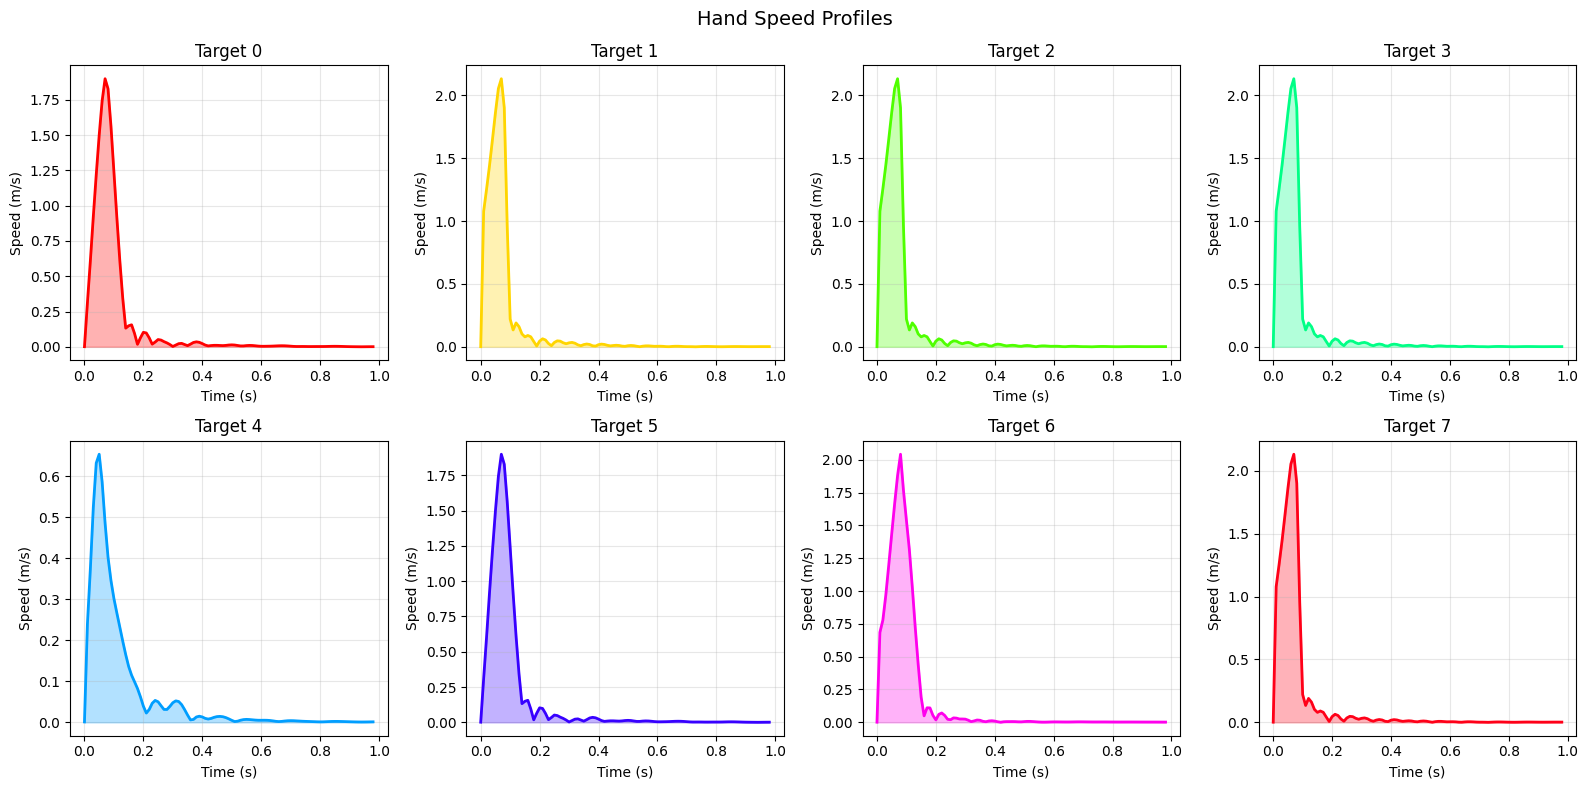

In [13]:
# Compute velocity from trajectories
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, traj in enumerate(all_trajectories):
    ax = axes[i // 4, i % 4]
    
    # Compute velocity (finite difference)
    velocity = jnp.diff(traj, axis=0) / arm_params.dt
    speed = jnp.sqrt(jnp.sum(velocity ** 2, axis=1))
    
    t = np.arange(len(speed)) * arm_params.dt
    ax.plot(t, speed, color=colors[i], linewidth=2)
    ax.fill_between(t, 0, speed, color=colors[i], alpha=0.3)
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Speed (m/s)')
    ax.set_title(f'Target {i}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Hand Speed Profiles', fontsize=14)
plt.tight_layout()
plt.show()

## VII. Save and Load Policy

You can save trained policies using equinox serialization:

In [14]:
import pickle

# Save policy
save_path = 'trained_policy.pkl'

# Extract arrays and structure
policy_arrays, policy_static = eqx.partition(policy, eqx.is_array)

with open(save_path, 'wb') as f:
    pickle.dump({
        'arrays': jax.tree.map(np.array, policy_arrays),
        'static': policy_static,
        'config': {
            'obs_dim': obs_dim,
            'action_dim': action_dim,
            'hidden_size': hidden_size,
        }
    }, f)

print(f"Policy saved to {save_path}")

# Load policy
with open(save_path, 'rb') as f:
    saved = pickle.load(f)

loaded_arrays = jax.tree.map(jnp.array, saved['arrays'])
loaded_policy = eqx.combine(loaded_arrays, saved['static'])

print("Policy loaded successfully!")

# Verify
test_pos, _ = evaluate_trajectory(loaded_policy, arm_state, targets[0])
print(f"Test trajectory final position: {test_pos[-1]}")

Policy saved to trained_policy.pkl
Policy loaded successfully!
Test trajectory final position: [0.20622325 0.46091014]


## Summary

In this notebook we covered:

1. **GRU Policy**: Recurrent neural network for motor control
2. **Task Definition**: Center-out reaching with targets
3. **Loss Function**: 
   - **L1 position loss**: Absolute error on full trajectory (reach and hold)
   - **Effort cost**: Mean squared muscle activation (metabolic cost proxy)
   - **Jerk penalty**: Smoothness regularization (3rd derivative of position)
4. **Training**: Using optax and equinox for gradient-based optimization
5. **Evaluation**: Visualizing learned trajectories and muscle activations
6. **Velocity Profiles**: Analyzing movement kinematics
7. **Save/Load**: Persisting trained policies

### Key Takeaways:

- **End-to-end differentiability**: Gradients flow through entire simulation
- **Equinox for NNs**: Clean functional neural network library
- **Optax for optimization**: Flexible optimizer library
- **JIT compilation**: Fast training iterations
- **vmap for batching**: Parallel training over batch
- **Biologically plausible costs**: Effort and smoothness penalties encourage realistic movements